# Array Factor Calculculation

The purpose of the notebook is to quickly iterate through different simple uniform antenna arrays and their resultant array factors.
We start by defining some basic constants we'll use throughout.

1.5384615384615385


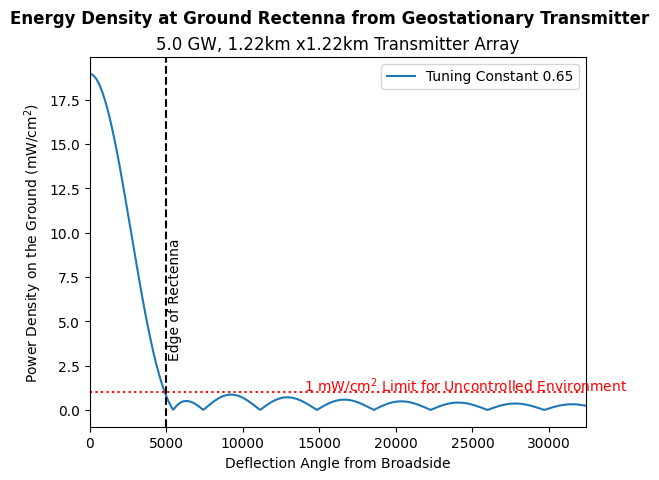

5543494737.179682


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Basic Constants
f = 2.45e9 #Hz
c = 299792458 #m/s
wl = c/f
k = 2*np.pi/wl
elementSpacing = wl/2

# Array Dimensions
xElements = 20000
yElements = 20000

xVals = np.arange(xElements)*elementSpacing
yVals = np.arange(yElements)*elementSpacing
xDim = xVals[-1]
yDim = yVals[-1]

numPoints = 500
constantNum = 1

tuningConstants = np.linspace(0.65,.65,num=constantNum)
powerDensity = np.zeros((constantNum, numPoints))

for i in range(constantNum):
    # Create Hamming Window
    hammingWindow = np.zeros(xElements)
    tuningConst = tuningConstants[i]
    for n in range(xElements):
        hammingWindow[n] = tuningConst - (1-tuningConst)*np.cos(2*np.pi*n/xElements)
    hammingWindow *= xElements/np.sum(hammingWindow)
    print(np.max(hammingWindow))

    # Array Factor Points
    angleSpread = 0.05
    thetas = np.deg2rad(np.linspace(0, angleSpread, num=numPoints)) # sweep window in degrees
    arrayFactors = np.zeros(numPoints)

    # Array Factor Calculation (since z and phi = 0, calculations can be batched/simplified significantly)
    for point in range(numPoints):
        a = np.multiply(np.exp(xVals * -1j * k * np.sin(thetas[point])), hammingWindow)
        arrayFactors[point] = yElements * np.absolute(np.sum(a))

    # Calculate total gain (since sweep angle is so small, using max gain of dipole for now)
    totalGain = arrayFactors * 1.64

    # Convert AF to dB
    arrayFactorLog = 10 * np.log10(arrayFactors)

    # Convert AF to power density at receive site
    txToRxDistance = 37120e3
    txPower = 5e9

    powerDensity[i] = totalGain*(txPower/(4*np.pi*txToRxDistance*txToRxDistance))*0.1

    # Convert angles to distance from center of rectenna
    distanceFromCenter = txToRxDistance * np.sin(thetas)

for i in range(constantNum):
    plt.plot(distanceFromCenter, powerDensity[i], label=f"Tuning Constant {tuningConstants[i]}")
plt.legend()
plt.suptitle(f"Energy Density at Ground Rectenna from Geostationary Transmitter", weight="bold")
plt.title(f"{txPower/1e9} GW, {xDim/1000:.2f}km x{yDim/1000:.2f}km Transmitter Array")
plt.xlabel("Deflection Angle from Broadside")
plt.ylabel("Power Density on the Ground (mW/cm$^2$)")
plt.axvline(5000, linestyle='dashed', color='black')
plt.text(5100, 3, 'Edge of Rectenna', rotation=90)
plt.axhline(1, linestyle='dotted', color='red')
plt.text(14000, 1.1, '1 mW/cm$^2$ Limit for Uncontrolled Environment', color='red')
plt.xlim(distanceFromCenter[0], distanceFromCenter[-1])
plt.show()

power = 0
for i in range(76):
    power += np.pi*(powerDensity[0][i+1])*(distanceFromCenter[i+1]*distanceFromCenter[i+1] - distanceFromCenter[i]*distanceFromCenter[i])
print(power*10)

AF\(θ, φ\) = summation for all elements\(exp\(\-jk\(xsinθcosφ\+ysinθsinφ\+zcosθ\)\)\)

